# Industrial Surface Defect Detection Using Deep Learning and Explainable AI
## Milestone 2 — Standard Custom CNN and Transfer Learning Training

**Dataset:** MVTec AD — Tile  
**Primary task:** Binary classification (`good` vs. `defective`)  
**Input size:** 224 × 224  
**Fixed split source:** `tile_supervised_splits.csv`

This notebook trains the approved Custom CNN baseline and frozen-backbone MobileNetV2 model on the complete training split. Model selection uses validation loss only. The test split remains reserved and is not evaluated.

## 1. Experimental safeguards

- The leakage-safe manifests from Milestone 1 remain fixed.
- Augmentation is active only while training.
- Class weights are calculated from the full training split only.
- Validation data controls early stopping, learning-rate reduction, and checkpoint selection.
- Test data is verified as metadata but is not evaluated.
- Both models use identical train/validation manifests and metrics.
- No hyperparameter tuning or fine-tuning is performed.

In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
RUN_MODE = "standard"
RUN_TRANSFER_TRAINING = True

PROJECT_ROOT = Path.cwd().resolve()
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "tile" / "manifests" / "tile_supervised_splits.csv"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_ROOT / "models" / "milestone2"
HISTORY_DIR = OUTPUT_ROOT / "histories" / "milestone2"
FIGURE_DIR = OUTPUT_ROOT / "figures" / "milestone2"
KERAS_CACHE_DIR = OUTPUT_ROOT / "keras_cache"

os.environ["KERAS_HOME"] = str(KERAS_CACHE_DIR)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Available GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"Run mode: {RUN_MODE}")
print(f"Transfer training enabled: {RUN_TRANSFER_TRAINING}")

TensorFlow version: 2.21.0
Available GPUs: []
Run mode: standard
Transfer training enabled: True


## 2. Runtime modes

| Mode | Images | Epochs | Purpose |
|---|---:|---:|---|
| Smoke | 64 train / 32 validation | 1 | Verify paths, tensors, training, and metrics |
| Fast | Full dataset | 5 | Quick development run |
| Standard | Full dataset | up to 20 | Default experiment with early stopping |
| Full | Full dataset | up to 35 | Carefully approved extended run |

This executed notebook uses **Standard** mode on all training and validation images. Early stopping may finish before 20 epochs. No hyperparameter search or fine-tuning is performed.

In [2]:
MODE_CONFIG = {
    "smoke": {"train_limit": 64, "validation_limit": 32, "epochs": 1},
    "fast": {"train_limit": None, "validation_limit": None, "epochs": 5},
    "standard": {"train_limit": None, "validation_limit": None, "epochs": 20},
    "full": {"train_limit": None, "validation_limit": None, "epochs": 35},
}
config = MODE_CONFIG[RUN_MODE]
display(pd.DataFrame(MODE_CONFIG).T)

,train_limit,validation_limit,epochs
smoke,64.0,32.0,1.0
fast,NaN,NaN,5.0
standard,NaN,NaN,20.0
full,NaN,NaN,35.0


## 3. Load and verify the fixed manifests

The test rows are verified but not passed to a model in smoke mode.

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {
    "source_path", "relative_path", "binary_class", "binary_label",
    "defect_type", "split", "group_id", "sha256",
}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Missing manifest columns: {sorted(missing_columns)}")

assert len(manifest) == 347
assert manifest["relative_path"].is_unique
assert manifest.groupby("group_id")["split"].nunique().max() == 1
assert manifest.groupby("sha256")["split"].nunique().max() == 1
assert manifest["source_path"].map(lambda value: Path(value).is_file()).all()

train_frame = manifest.loc[manifest["split"] == "train"].copy()
validation_frame = manifest.loc[manifest["split"] == "validation"].copy()
test_frame = manifest.loc[manifest["split"] == "test"].copy()

print(f"Train images: {len(train_frame)}")
print(f"Validation images: {len(validation_frame)}")
print(f"Reserved test images: {len(test_frame)}")
display(pd.crosstab(manifest["split"], manifest["binary_class"]))

Train images: 242
Validation images: 54
Reserved test images: 51


binary_class,defective,good
split,,
test,12,39
train,58,184
validation,14,40


## 4. Create deterministic smoke subsets

Sampling is stratified by the binary label and is used only to make the pipeline test inexpensive. Full runs use every image from the fixed train and validation manifests.

In [4]:
def stratified_limit(frame: pd.DataFrame, limit: int | None, seed: int) -> pd.DataFrame:
    if limit is None or limit >= len(frame):
        return frame.sample(frac=1, random_state=seed).reset_index(drop=True)

    fractions = frame["binary_label"].value_counts(normalize=True)
    selected_parts = []
    remaining = limit
    labels = sorted(fractions.index)
    for position, label in enumerate(labels):
        subset = frame.loc[frame["binary_label"] == label]
        if position == len(labels) - 1:
            count = remaining
        else:
            count = max(1, round(limit * fractions[label]))
            remaining -= count
        selected_parts.append(subset.sample(n=min(count, len(subset)), random_state=seed + int(label)))
    return pd.concat(selected_parts).sample(frac=1, random_state=seed).reset_index(drop=True)


active_train = stratified_limit(train_frame, config["train_limit"], SEED)
active_validation = stratified_limit(validation_frame, config["validation_limit"], SEED + 10)

print("Active training subset:")
display(active_train["binary_class"].value_counts().rename("count").to_frame())
print("Active validation subset:")
display(active_validation["binary_class"].value_counts().rename("count").to_frame())

Active training subset:


,count
binary_class,
good,184
defective,58


Active validation subset:


,count
binary_class,
good,40
defective,14


## 5. Build the input pipeline

Images are decoded as RGB, resized to 224 × 224, and batched. Augmentation is not part of the validation pipeline. It is implemented as training-aware Keras layers inside each model.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_resize(path: tf.Tensor, label: tf.Tensor):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_png(image_bytes, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE, antialias=True)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)


def make_dataset(frame: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = frame["source_path"].astype(str).to_numpy()
    labels = frame["binary_label"].astype(np.float32).to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_resize, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    return dataset.prefetch(AUTOTUNE)


train_dataset = make_dataset(active_train, training=True)
validation_dataset = make_dataset(active_validation, training=False)

sample_images, sample_labels = next(iter(train_dataset))
print(f"Image batch shape: {sample_images.shape}")
print(f"Label batch shape: {sample_labels.shape}")
print(f"Pixel range: {sample_images.numpy().min():.1f} to {sample_images.numpy().max():.1f}")

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Pixel range: 27.3 to 255.0


## 6. Training-only augmentation and class weights

The augmentation policy is deliberately conservative for tile textures: small flips, rotations, zooms, contrast changes, and translations. No augmented image is written to disk.

Class weights use all 242 training images, not the validation or test splits.

In [6]:
augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        tf.keras.layers.RandomRotation(0.05, fill_mode="reflect", seed=SEED),
        tf.keras.layers.RandomZoom(0.08, fill_mode="reflect", seed=SEED),
        tf.keras.layers.RandomTranslation(0.05, 0.05, fill_mode="reflect", seed=SEED),
        tf.keras.layers.RandomContrast(0.10, seed=SEED),
    ],
    name="training_augmentation",
)

train_counts = train_frame["binary_label"].value_counts().sort_index()
class_weights = {
    int(label): float(len(train_frame) / (len(train_counts) * count))
    for label, count in train_counts.items()
}
print("Full training counts:")
display(train_counts.rename("count").to_frame())
print("Candidate class weights:", class_weights)

Full training counts:


,count
binary_label,
0,184
1,58


Candidate class weights: {0: 0.657608695652174, 1: 2.086206896551724}


## 7. Custom CNN baseline

The baseline is intentionally compact and interpretable:

1. rescale pixels to [0, 1];
2. apply training-only augmentation;
3. learn three convolutional feature levels;
4. stabilize optimization with batch normalization;
5. reduce parameters with global average pooling;
6. regularize with dropout;
7. output a defective-class probability with a sigmoid.

The model uses binary cross-entropy and Adam. Recall and PR-AUC are included because missing a defective tile is operationally important.

In [7]:
def classification_metrics():
    return [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
    ]


def build_custom_cnn() -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)
    x = augmentation(x)
    for filters in (32, 64, 128):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.35, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="defective_probability")(x)
    model = tf.keras.Model(inputs, outputs, name="custom_cnn_baseline")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=classification_metrics(),
    )
    return model


baseline_model = build_custom_cnn()
baseline_model.summary()
print(f"Total parameters: {baseline_model.count_params():,}")

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defective_probability (Dense)   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,049 (367.38 KB)

 Trainable params: 93,601 (365.63 KB)

 Non-trainable params: 448 (1.75 KB)

Total parameters: 94,049


## 9. Train the Custom CNN baseline

The complete training split is used. Training can stop before 20 epochs when validation loss fails to improve for four consecutive epochs.

## 8. Validation-based callbacks

Early stopping, checkpointing, and learning-rate reduction monitor validation loss only. The best checkpoint is saved for later evaluation.

In [8]:
def make_callbacks(model_name: str):
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

print("Validation-based callbacks are ready.")

Validation-based callbacks are ready.


In [9]:
baseline_start = time.perf_counter()
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=config["epochs"],
    class_weight=class_weights,
    callbacks=make_callbacks("custom_cnn_baseline"),
    verbose=2,
)
baseline_seconds = time.perf_counter() - baseline_start

print(f"Baseline training runtime: {baseline_seconds / 60:.2f} minutes")
print(f"Baseline epochs completed: {len(baseline_history.history['loss'])}")

Epoch 1/20
16/16 - 72s - 5s/step - accuracy: 0.6488 - loss: 0.6951 - pr_auc: 0.3611 - precision: 0.3689 - recall: 0.6552 - roc_auc: 0.6886 - val_accuracy: 0.2593 - val_loss: 0.7714 - val_pr_auc: 0.4458 - val_precision: 0.2593 - val_recall: 1.0000 - val_roc_auc: 0.7607 - learning_rate: 0.0010
Epoch 2/20
16/16 - 24s - 2s/step - accuracy: 0.7314 - loss: 0.5128 - pr_auc: 0.5985 - precision: 0.4653 - recall: 0.8103 - roc_auc: 0.8344 - val_accuracy: 0.2593 - val_loss: 1.1136 - val_pr_auc: 0.2557 - val_precision: 0.2593 - val_recall: 1.0000 - val_roc_auc: 0.5134 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
16/16 - 25s - 2s/step - accuracy: 0.7521 - loss: 0.5173 - pr_auc: 0.5427 - precision: 0.4884 - recall: 0.7241 - roc_auc: 0.8336 - val_accuracy: 0.2593 - val_loss: 1.3059 - val_pr_auc: 0.3461 - val_precision: 0.2593 - val_recall: 1.0000 - val_roc_auc: 0.6607 - learning_rate: 0.0010
Epoch 4/20
16/16 - 23s - 1s/step - accuracy:

## 10. Train the frozen MobileNetV2 transfer model

The ImageNet-pretrained backbone remains frozen. Only the classification head is trainable. This evaluates transfer learning without fine-tuning.

In [10]:
def build_mobilenetv2_transfer(weights: str = "imagenet") -> tuple[tf.keras.Model, tf.keras.Model]:
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(*IMAGE_SIZE, 3),
        include_top=False,
        weights=weights,
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
    x = augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.30, seed=SEED)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="defective_probability")(x)
    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=classification_metrics(),
    )
    return model, backbone


if RUN_TRANSFER_TRAINING:
    transfer_model, transfer_backbone = build_mobilenetv2_transfer(weights="imagenet")
    transfer_model.summary()
    transfer_start = time.perf_counter()
    transfer_history = transfer_model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=config["epochs"],
        class_weight=class_weights,
        callbacks=make_callbacks("mobilenetv2_transfer"),
        verbose=2,
    )
    transfer_seconds = time.perf_counter() - transfer_start
    print(f"Transfer training runtime: {transfer_seconds / 60:.2f} minutes")
    print(f"Transfer epochs completed: {len(transfer_history.history['loss'])}")
else:
    print("Transfer training disabled.")

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defective_probability (Dense)   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
16/16 - 63s - 4s/step - accuracy: 0.6901 - loss: 0.6352 - pr_auc: 0.4864 - precision: 0.3976 - recall: 0.5690 - roc_auc: 0.6927 - val_accuracy: 0.8519 - val_loss: 0.5407 - val_pr_auc: 0.7168 - val_precision: 0.7143 - val_recall: 0.7143 - val_roc_auc: 0.7920 - learning_rate: 0.0010
Epoch 2/20
16/16 - 13s - 836ms/step - accuracy: 0.7149 - loss: 0.5617 - pr_auc: 0.6368 - precision: 0.4353 - recall: 0.6379 - roc_auc: 0.7562 - val_accuracy: 0.8889 - val_loss: 0.4323 - val_pr_auc: 0.8019 - val_precision: 0.8333 - val_recall: 0.7143 - val_roc_auc: 0.8857 - learning_rate: 0.0010
Epoch 3/20
16/16 - 12s - 766ms/step - accuracy: 0.8264 - loss: 0.4694 - pr_auc: 0.7670 - precision: 0.6212 - recall: 0.7069 - roc_auc: 0.8450 - val_accuracy: 0.8704 - val_loss: 0.3772 - val_pr_auc: 0.8446 - val_precision: 0.8182 - val_recall: 0.6429 - val_roc_auc: 0.9214 - learning_rate: 0.0010
Epoch 4/20
16/16 - 14s - 863ms/step - accuracy: 0.7810 - loss: 0.5254 - pr_auc: 0.6973 - precision: 0.5342 - recall

## 11. Save histories and compare validation performance

Histories, learning curves, and a validation-only comparison table are saved outside the raw-data directory. These are development results, not final test results.

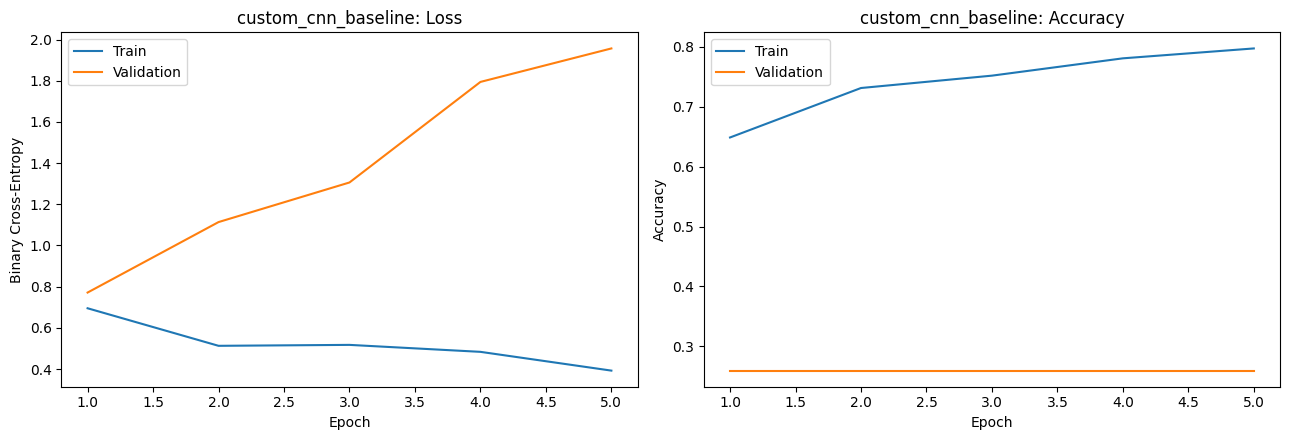

Saved: D:\Final Project\outputs\histories\milestone2\custom_cnn_baseline_history.csv
Saved: D:\Final Project\outputs\figures\milestone2\custom_cnn_baseline_learning_curves.png


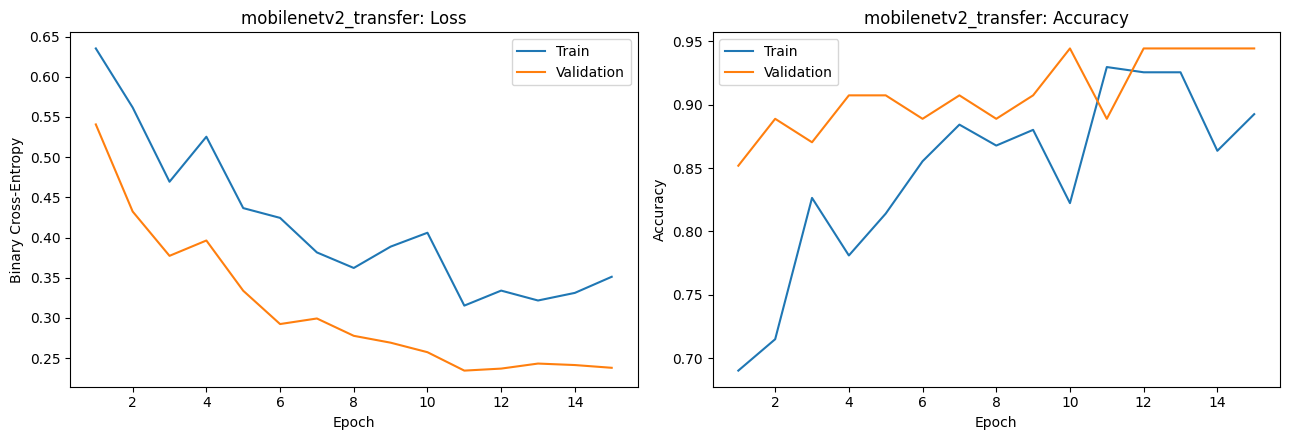

Saved: D:\Final Project\outputs\histories\milestone2\mobilenetv2_transfer_history.csv
Saved: D:\Final Project\outputs\figures\milestone2\mobilenetv2_transfer_learning_curves.png


,model,epochs_completed,best_epoch_by_val_loss,best_val_loss,val_accuracy_at_best_epoch,val_precision_at_best_epoch,val_recall_at_best_epoch,val_roc_auc_at_best_epoch,val_pr_auc_at_best_epoch
0,mobilenetv2_transfer,15,11,0.2345,0.8889,0.8333,0.7143,0.9750,0.9369
1,custom_cnn_baseline,5,1,0.7714,0.2593,0.2593,1.0000,0.7607,0.4458


Saved: D:\Final Project\outputs\histories\milestone2\standard_training_validation_comparison.csv
The test split was not evaluated.


In [11]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

histories = {
    "custom_cnn_baseline": baseline_history.history,
    "mobilenetv2_transfer": transfer_history.history,
}
comparison_records = []

for model_name, history in histories.items():
    history_frame = pd.DataFrame(history)
    history_frame.index = np.arange(1, len(history_frame) + 1)
    history_frame.index.name = "epoch"
    history_path = HISTORY_DIR / f"{model_name}_history.csv"
    history_frame.to_csv(history_path)

    best_epoch = int(history_frame["val_loss"].idxmin())
    best_row = history_frame.loc[best_epoch]
    comparison_records.append({
        "model": model_name,
        "epochs_completed": len(history_frame),
        "best_epoch_by_val_loss": best_epoch,
        "best_val_loss": float(best_row["val_loss"]),
        "val_accuracy_at_best_epoch": float(best_row["val_accuracy"]),
        "val_precision_at_best_epoch": float(best_row["val_precision"]),
        "val_recall_at_best_epoch": float(best_row["val_recall"]),
        "val_roc_auc_at_best_epoch": float(best_row["val_roc_auc"]),
        "val_pr_auc_at_best_epoch": float(best_row["val_pr_auc"]),
    })

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history_frame.index, history_frame["loss"], label="Train")
    axes[0].plot(history_frame.index, history_frame["val_loss"], label="Validation")
    axes[0].set_title(f"{model_name}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy")
    axes[0].legend()

    axes[1].plot(history_frame.index, history_frame["accuracy"], label="Train")
    axes[1].plot(history_frame.index, history_frame["val_accuracy"], label="Validation")
    axes[1].set_title(f"{model_name}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    figure_path = FIGURE_DIR / f"{model_name}_learning_curves.png"
    plt.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {history_path}")
    print(f"Saved: {figure_path}")

comparison = pd.DataFrame(comparison_records).sort_values("best_val_loss").reset_index(drop=True)
comparison_path = HISTORY_DIR / "standard_training_validation_comparison.csv"
comparison.to_csv(comparison_path, index=False)
display(comparison.round(4))
print(f"Saved: {comparison_path}")
print("The test split was not evaluated.")

## Conclusions

- The fixed leakage-safe manifests were revalidated.
- The complete training and validation splits were used.
- Augmentation was restricted to training behavior.
- Class weights were calculated from training data only.
- The Custom CNN and frozen MobileNetV2 were trained with validation-based callbacks.
- Best checkpoints, histories, learning curves, and a validation comparison were saved.
- The test split was not used.
- Fine-tuning, threshold selection, and final evaluation remain separate stages.

### Next decision

Review validation results and learning curves before approving fine-tuning or final model selection.